In [1]:
import os
os.chdir("./..")

from PVDatasetWithHistory import PVDatasetWithHistory

ds = PVDatasetWithHistory(r"/projects/p1364-25-2/datasets/pv/processed/nwp_0h", previous_days=0, split="test")

In [3]:
len(ds.installation_id_to_idx)

3713

In [4]:
x, y, metadata = ds[0]

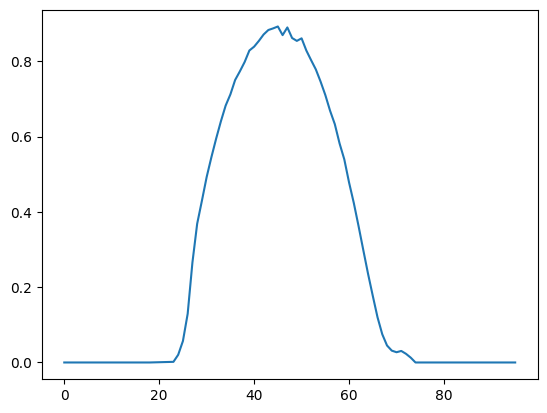

In [6]:
import matplotlib.pyplot as plt

plt.plot(y.cpu().numpy(), label="True")

In [ ]:
metadata["tilt"]

IndexError: Dimension out of range (expected to be in range of [-1, 0], but got 1)

In [52]:
import torch

albedo = torch.tensor(0.25)
u0 = torch.tensor(25.0)
u1 = torch.tensor(7.0)
k_a = torch.tensor(1.0)
k_d = torch.tensor(-6.0)
tc_d = torch.tensor(0.0)
k_rs = torch.tensor(1e-3)
k_rsh = torch.tensor(1e-3)

dhi = x['dhi']
ghi = x['ghi']
dni = x['dni']
wind_speed = x['wind_speed']
temp_air = x['temp_air']

tilt = metadata["tilt"]
orient = metadata["orientation"]

sky_diffuse = dhi * ((1 + torch.cos(tilt)) * 0.5)
ground_diffuse = ghi * (albedo * (1 - torch.cos(tilt)) * 0.5)

projection = (
    torch.cos(tilt) * torch.cos(x['solar_zenith']) +
    torch.sin(tilt) * torch.sin(x['solar_zenith']) *
    torch.cos(x['solar_azimuth'] - orient))

projection = torch.clip(projection, -1, 1)

aoi = torch.acos(projection)

poa_direct = torch.maximum(dni * torch.cos(aoi), torch.tensor(0.0))
poa_diffuse = sky_diffuse + ground_diffuse
poa_global = poa_direct + poa_diffuse

total_loss_factor = u0 + u1 * wind_speed
heat_input = poa_global
temp_difference = heat_input / total_loss_factor
pv_temp = temp_air + temp_difference

# normalize the irradiance
s = poa_global / 1000.0

# obtain the difference from reference temperature
dt = pv_temp - 25.0

s_o     = 10**(k_d + (dt * tc_d))
s_o_ref = 10**(k_d)

v  = torch.log(s / s_o     + 1)
v /= torch.log(1 / s_o_ref + 1)

eta = k_a * ((1 + k_rs + k_rsh) * v - k_rs * s - k_rsh * v**2)

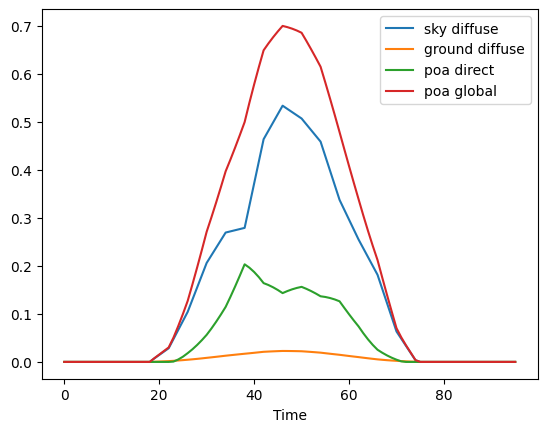

In [79]:
#plt.plot(dhi.cpu().numpy() / 1000.0, label="dhi")
#plt.plot(s.cpu().numpy(), label="s")
#plt.plot(aoi.cpu().numpy(), label="aoi")
#plt.plot(projection.cpu().numpy(), label="projection")
#plt.plot(dt.cpu().numpy() / 8, label="temp difference")
#plt.plot(v.cpu().numpy(), label="v")
plt.plot(sky_diffuse.cpu().numpy() / 1000.0, label="sky diffuse")
plt.plot(ground_diffuse.cpu().numpy() / 1000.0, label="ground diffuse")
plt.plot(poa_direct.cpu().numpy() / 1000.0, label="poa direct")
plt.plot(poa_global.cpu().numpy() / 1000.0, label="poa global")
#plt.plot(torch.cos(tilt).cpu().numpy(), label="cos(tilt)")
plt.xlabel("Time")
plt.legend()
plt.show()

In [2]:
from models.ADRInspired import ADRInspired as ADR
from utils.config import load_config
import torch

config = load_config("./config/ADR.yaml")
model_fit = ADR(config)
model_fit.load_state_dict(torch.load(r"C:\Users\peter\Repos\ENFIELD-PIML\checkpoints\PV-PIML\fit_normalized\epoch=7-step=32768.ckpt", weights_only=False)["state_dict"])

model_default = ADR(config)

W0504 23:29:14.295000 12936 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


In [3]:
for name, param in model_default.named_parameters():
    print(f"{name}: {param.detach().cpu().numpy():.3f}")

albedo: 0.250
u0: 25.000
u1: 7.000
k_a: 1.000
k_d: -6.000
tc_d: 0.000
k_rs: 0.001
k_rsh: 0.001


In [4]:
for name, param in model_fit.named_parameters():
    print(f"{name}: {param.detach().cpu().numpy():.3f}")

albedo: 0.250
u0: 26.848
u1: 5.861
k_a: 0.764
k_d: -7.414
tc_d: 0.045
k_rs: 0.636
k_rsh: 0.876


In [5]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

import random

x, y, metadata = ds[random.randint(0, len(ds)-1)]
metadata_tensors = {}
for k, v in metadata.items():
    try:
        metadata_tensors[k] = torch.tensor(v).unsqueeze(0)
    except (TypeError, ValueError):
        metadata_tensors[k] = [v]

y_hat = model_fit([t.unsqueeze(0) for t in x], metadata_tensors)
fitted_prediction = y_hat.detach().numpy()

y_hat = model_default([t.unsqueeze(0) for t in x], metadata_tensors)
default_prediction = y_hat.detach().numpy()

fig, ax = plt.subplots(1, 1, figsize=(8, 4.5))
ax.plot(pd.to_datetime(x[-1], unit="s"), y*4000, label="output")
ax.plot(pd.to_datetime(x[-1], unit="s"), fitted_prediction[0], label="ADR fitted")
ax.plot(pd.to_datetime(x[-1], unit="s"), default_prediction[0], label="ADR default")
ax.set_xlabel("Time")
ax.set_ylabel("Output")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.xticks(rotation=45, ha='right')
ax.set_ylim(0,9610)
plt.show()

AttributeError: 'str' object has no attribute 'unsqueeze'